# Dataset Demo

In [7]:
!pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 4.9 MB/s eta 0:00:00m eta 0:00:010:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.8/374.8 KB 2.7 MB/s eta 0:00:002.5 MB/s eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.4/740.4 KB 6.8 MB/s eta 0:00:007.1 MB/s eta 0:00:01


In [1]:
from PIL import Image
import pillow_avif
from zipp import Path as ZipPath
import io
from mpl_toolkits.mplot3d import axes3d, Axes3D #<-- Note the capitalization! 
import numpy as np
from plyfile import PlyData

In [2]:
import sys
sys.path.append('./demos/keypoints.py')
sys.path.append('./demos/mesh.py')
sys.path.append('./demos/segmentation.py')

import demos.keypoints, demos.mesh, demos.segmentation

### Image Sample

In [3]:
camera_id = '400939'
frame_id = 140900
#AVA_ROOT = "../datasets/AVA_dataset/"
ava_dir = "/home/kirillfish/Datasets/ava-256"
subject_id = "20230405--1635--AAN112"

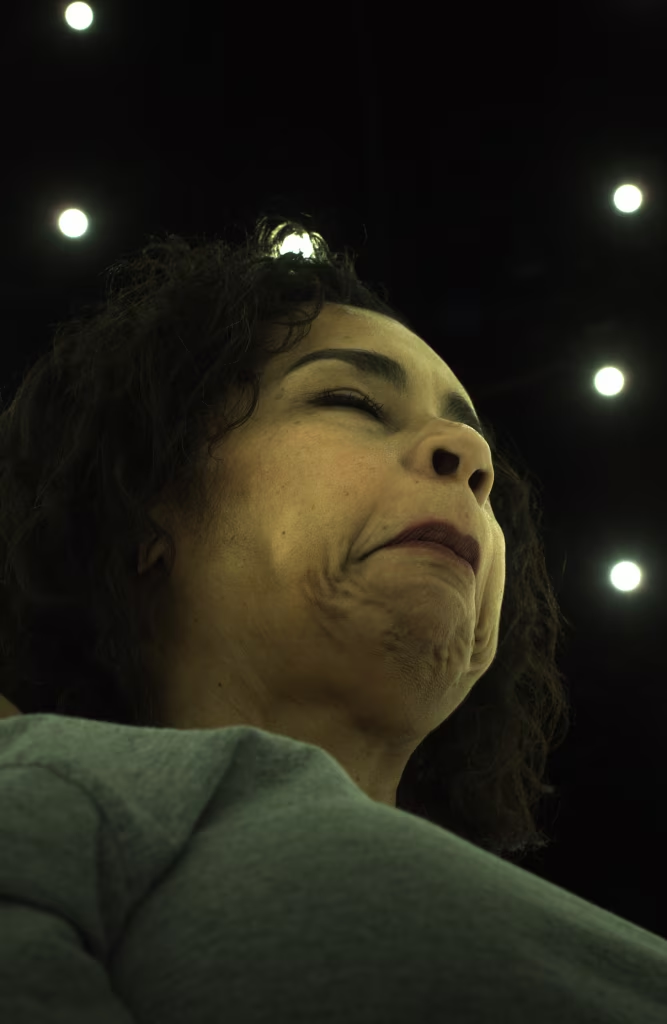

In [4]:
base_dir = f"{ava_dir}/{subject_id}/decoder/"
path = ZipPath(
                base_dir + "image/" + f"cam{camera_id}.zip",
                f"cam{camera_id}/{int(frame_id):06d}.avif",
            )
img_bytes = path.read_bytes()
image = Image.open(io.BytesIO(img_bytes))
display(image)

## Keypoints Demo

### Keypoints Projected on Image

Loaded camera calibration
Loaded keypoints of shape (160, 6)


<module 'matplotlib.pyplot' from '/home/kirillfish/.local/lib/python3.10/site-packages/matplotlib/pyplot.py'>

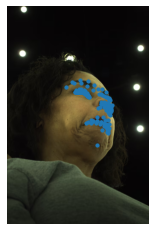

In [5]:
demos.keypoints.plot_keypoints_on_image(ava_dir, subject_id, base_dir, camera_id, frame_id)

### Keypoints in 3D

Loaded keypoints of shape (160, 6)


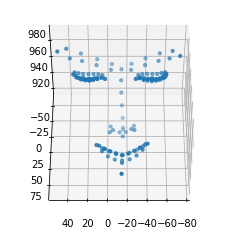

In [13]:
demos.keypoints.plot_keypoints_3d(ava_dir, subject_id, base_dir, frame_id, elev=50, azim=90, roll=0, showfig=True)

### Checking keypoints

In [15]:
import numpy as np
keypoint_raw_path = ZipPath(
                base_dir + "keypoints_3d/" + f"keypoints_3d.zip",
                f"{int(frame_id):06d}.npy",
            )
kps_bytes = keypoint_raw_path.read_bytes()
kps = np.load(io.BytesIO(kps_bytes))

In [17]:
kps.shape

(160, 6)

In [18]:
kps[0]

array([  0.        , -14.17659832, -49.43478789, 959.40064905,
       109.        , 109.        ])

### Checking .ply files

In [48]:
ply_path = ZipPath(base_dir + "kinematic_tracking/registration_vertices.zip",  f"{int(frame_id):06d}.ply")
ply_bytes = io.BytesIO(ply_path.read_bytes())
plydata = PlyData.read(ply_bytes)
verts = plydata["vertex"].data
verts = np.array([list(element) for element in verts])

In [37]:
plydata

PlyData((PlyElement('vertex', (PlyProperty('x', 'float'), PlyProperty('y', 'float'), PlyProperty('z', 'float')), count=7306, comments=[]),), text=False, byte_order='<', comments=[], obj_info=[])

In [51]:
plydata["faces"]

KeyError: 'faces'

In [43]:
verts.shape

(7306, 3)

In [49]:
verts[:20]

array([[-81.7519   , -42.348    , -55.6229   ],
       [-44.3066   , -69.0231   ,   2.61172  ],
       [-25.006    , -70.4386   ,  27.2506   ],
       [-48.5067   ,  -1.12135  ,  33.7757   ],
       [-36.472    ,  -8.95293  ,  42.3977   ],
       [-45.4276   ,   2.2946498,  35.7981   ],
       [-33.5083   ,  -5.93857  ,  43.5395   ],
       [-25.99     ,  35.9348   ,  33.0196   ],
       [-28.5096   ,  35.5089   ,  33.1963   ],
       [-35.5546   ,  34.3046   ,  32.9226   ],
       [-38.1682   ,  33.8576   ,  32.3988   ],
       [-42.1931   ,  33.4717   ,  30.553    ],
       [-43.1613   ,  32.4035   ,  29.1267   ],
       [-38.9337   ,  32.8543   ,  31.1032   ],
       [-36.9094   ,  33.3548   ,  31.8985   ],
       [-31.7676   ,  34.1113   ,  32.8917   ],
       [-29.4458   ,  34.6495   ,  33.2733   ],
       [-27.5258   ,  34.835    ,  32.9145   ],
       [-19.9742   ,  33.9082   ,  31.9321   ],
       [-12.5619   , -51.3013   ,  49.1307   ]], dtype=float32)

## Mesh Demo

### Mesh Projection on 2D image

Loaded camera calibration


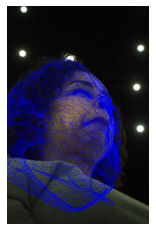

In [12]:
demos.mesh.plot_mesh_on_image(ava_dir, subject_id, base_dir, camera_id, frame_id, savefig=False, showfig=True)

### Mesh Visualization in 3D

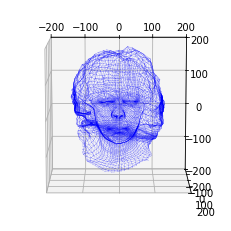

In [11]:
demos.mesh.plot_mesh_3d(ava_dir, subject_id, base_dir, frame_id, elev=80, azim=90, roll=180, showfig=True)

## Segmentation demo

In [46]:
demos.segmentation.segmentation_demo(ava_dir, subject_id, base_dir, camera_id, frame_id)

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

<img src="segmentation_example.apng" width="300" align="center">